# Building & Training a Network in Keras

## Introduction

In this notebook, we take the next step after classic Machine Learning: we build, train, and evaluate our **first Artificial Neural Network (ANN)** using TensorFlow's **Keras** API.

**What this notebook covers:**

- **Building a neural network with Keras** — using the `Sequential` API to stack simple `Dense` (fully connected) layers, the same way you'd stack building blocks, without writing the underlying math (forward propagation, backpropagation, optimization) by hand.
- **Hyperparameters** — the settings *we* choose before training starts (as opposed to the weights the network learns on its own). In this notebook that includes things like the number of layers, the number of neurons per layer, the activation functions, the optimizer (`adam`), the loss function (`binary_crossentropy`), the batch size, and the number of epochs. Later, we also introduce `Dropout` (randomly turning off neurons during training) and `EarlyStopping` (stopping training once the model stops improving) as extra hyperparameters/techniques to fight overfitting.
- **The classic compile → fit → evaluate workflow** — mirroring the Scikit-learn workflow from previous weeks: `compile()` configures how the model learns, `fit()` trains it, and `evaluate()` checks how well it does on unseen data.
- **Reading the training history** — plotting training vs. validation loss and accuracy to diagnose whether the model is overfitting, underfitting, or learning well.
- **The dataset** — we use a real-world **cardiac (heart disease) dataset**, where the goal is to predict whether a person has heart disease based on their health indicators. This is a binary classification problem, and — importantly — the classes are **imbalanced** (far more healthy people than people with heart disease), which makes accuracy alone a misleading metric.
- **The big question** — after building a classic ML baseline earlier (Day 1), we now ask: **can a neural network / deep learning approach perform better than the classic ML model?** We build three versions of the network (a baseline, one with Dropout, and one with Dropout + Early Stopping), compare their metrics (accuracy, precision, recall, F1-score), and see whether adding these deep learning techniques actually helps — especially at the real goal: correctly catching people who have heart disease.

# Section 1:  Loading data and building the baseline model



---




### 1. Loading all the needed libraries

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix,  ConfusionMatrixDisplay


import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout

### 2. Data preprocessing and encoding

In [7]:
df = pd.read_csv("/content/drive/MyDrive/Datasets/heart_2020_raw.csv")
print("Shape:", df.shape)
display(df.head())

n_dupes = df.duplicated().sum()
df_clean = df.drop_duplicates().reset_index(drop=True)


binary_map = {"Yes": 1, "No": 0}
binary_cols = ["Smoking", "AlcoholDrinking", "Stroke", "DiffWalking",
               "PhysicalActivity", "Asthma", "KidneyDisease", "SkinCancer"]

for col in binary_cols:
    df_clean[col] = df_clean[col].map(binary_map)

df_clean["Sex"] = df_clean["Sex"].map({"Male": 1, "Female": 0})
df_clean["HeartDisease"] = df_clean["HeartDisease"].map(binary_map)

display(df_clean[binary_cols + ["Sex", "HeartDisease"]].head())

age_midpoints = {
    "18-24": 21, "25-29": 27, "30-34": 32, "35-39": 37, "40-44": 42,
    "45-49": 47, "50-54": 52, "55-59": 57, "60-64": 62, "65-69": 67,
    "70-74": 72, "75-79": 77, "80 or older": 82,
}
df_clean["AgeNumeric"] = df_clean["AgeCategory"].map(age_midpoints)

genhealth_map = {"Poor": 0, "Fair": 1, "Good": 2, "Very good": 3, "Excellent": 4}
df_clean["GenHealthNumeric"] = df_clean["GenHealth"].map(genhealth_map)

display(df_clean[["AgeCategory", "AgeNumeric", "GenHealth", "GenHealthNumeric"]].head())

df_model = df_clean.drop(
    columns=["AgeCategory", "GenHealth"]
)

df_model = pd.get_dummies(
    df_model,
    drop_first=True,
    dtype=int
)

df_model.info()

X = df_model.drop("HeartDisease", axis=1)
y = df_model["HeartDisease"]

print("X shape:", X.shape)
print("y shape:", y.shape)




Shape: (319795, 18)


,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,No,16.60,Yes,No,No,3.0,30.0,No,Female,55-59,White,Yes,Yes,Very good,5.0,Yes,No,Yes
1,No,20.34,No,No,Yes,0.0,0.0,No,Female,80 or older,White,No,Yes,Very good,7.0,No,No,No
2,No,26.58,Yes,No,No,20.0,30.0,No,Male,65-69,White,Yes,Yes,Fair,8.0,Yes,No,No
3,No,24.21,No,No,No,0.0,0.0,No,Female,75-79,White,No,No,Good,6.0,No,No,Yes
4,No,23.71,No,No,No,28.0,0.0,Yes,Female,40-44,White,No,Yes,Very good,8.0,No,No,No


,Smoking,AlcoholDrinking,Stroke,DiffWalking,PhysicalActivity,Asthma,KidneyDisease,SkinCancer,Sex,HeartDisease
0,1,0,0,0,1,1,0,1,0,0
1,0,0,1,0,1,0,0,0,0,0
2,1,0,0,0,1,1,0,0,1,0
3,0,0,0,0,0,0,0,1,0,0
4,0,0,0,1,1,0,0,0,0,0


,AgeCategory,AgeNumeric,GenHealth,GenHealthNumeric
0,55-59,57,Very good,3
1,80 or older,82,Very good,3
2,65-69,67,Fair,1
3,75-79,77,Good,2
4,40-44,42,Very good,3


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301717 entries, 0 to 301716
Data columns (total 24 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   HeartDisease                      301717 non-null  int64  
 1   BMI                               301717 non-null  float64
 2   Smoking                           301717 non-null  int64  
 3   AlcoholDrinking                   301717 non-null  int64  
 4   Stroke                            301717 non-null  int64  
 5   PhysicalHealth                    301717 non-null  float64
 6   MentalHealth                      301717 non-null  float64
 7   DiffWalking                       301717 non-null  int64  
 8   Sex                               301717 non-null  int64  
 9   PhysicalActivity                  301717 non-null  int64  
 10  SleepTime                         301717 non-null  float64
 11  Asthma                            301717 non-null  i

### 3. Data splitting
> Training / Validation / Testing

In [11]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.2,
    random_state=42,
    stratify=y_train_full
)

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

Training set: (193098, 23)
Validation set: (48275, 23)
Test set: (60344, 23)


### 4.Scalling all features

In [16]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

### 5.Get the number of the features
>this step is essential because  the first layer will have the same number of neurons as the features it receives

In [17]:
n_features = X_train_scaled.shape[1]
print("Number of features:", n_features)

Number of features: 23


In [18]:
input_shape=(23,)

### 7. Build the baseline neural network

In [19]:
model = Sequential([

    Dense(
        64,
        activation="relu",
        input_shape=(n_features,)
    ),

    Dense(
        32,
        activation="relu"
    ),

    Dense(
        1,
        activation="sigmoid"
    )
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### 8. Compile the model
> using adam modifier to control how the neural network updates its weights to reduce the loss.

In [20]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

### 9. Train the model

In [21]:
history = model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=50,
    batch_size=32
)

Epoch 1/50
6035/6035 ━━━━━━━━━━━━━━━━━━━━ 22s 3ms/step - accuracy: 0.9099 - loss: 0.2407 - val_accuracy: 0.9110 - val_loss: 0.2412
Epoch 2/50
6035/6035 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - accuracy: 0.9115 - loss: 0.2358 - val_accuracy: 0.9105 - val_loss: 0.2382
Epoch 3/50
6035/6035 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - accuracy: 0.9118 - loss: 0.2351 - val_accuracy: 0.9106 - val_loss: 0.2383
Epoch 4/50
6035/6035 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.9117 - loss: 0.2344 - val_accuracy: 0.9105 - val_loss: 0.2378
Epoch 5/50
6035/6035 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - accuracy: 0.9121 - loss: 0.2339 - val_accuracy: 0.9110 - val_loss: 0.2378
Epoch 6/50
6035/6035 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - accuracy: 0.9120 - loss: 0.2337 - val_accuracy: 0.9103 - val_loss: 0.2391
Epoch 7/50
6035/6035 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.9124 - loss: 0.2333 - val_accuracy: 0.9109 - val_loss: 0.2375
Epoch 8/50
6035/6035 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step - accuracy: 0.9122 - loss: 0

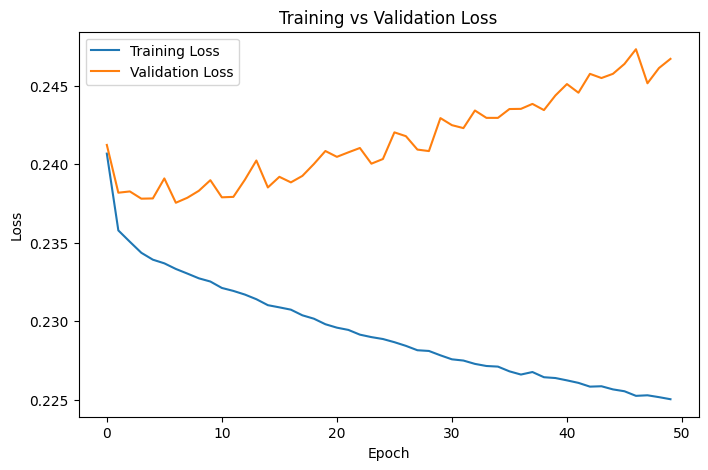

In [22]:
# ==========================================
# Plot Training and Validation Loss
# ==========================================

plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

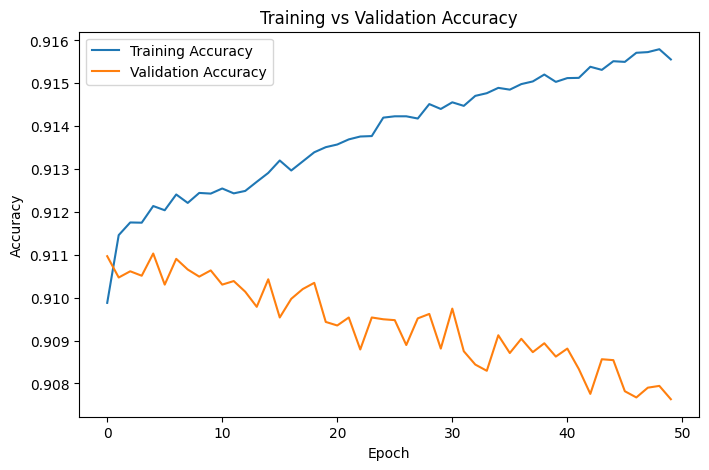

In [23]:
# ==========================================
# Plot Training and Validation Accuracy
# ==========================================

plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.show()

### 10. Evaluate the current baseline model

1886/1886 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9090 - loss: 0.2454

Test Loss: 0.2454
Test Accuracy: 0.9090

1886/1886 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step
CLASSIFICATION REPORT
                   precision    recall  f1-score   support

   No Disease (0)       0.92      0.99      0.95     54892
Heart Disease (1)       0.48      0.10      0.16      5452

         accuracy                           0.91     60344
        macro avg       0.70      0.54      0.56     60344
     weighted avg       0.88      0.91      0.88     60344



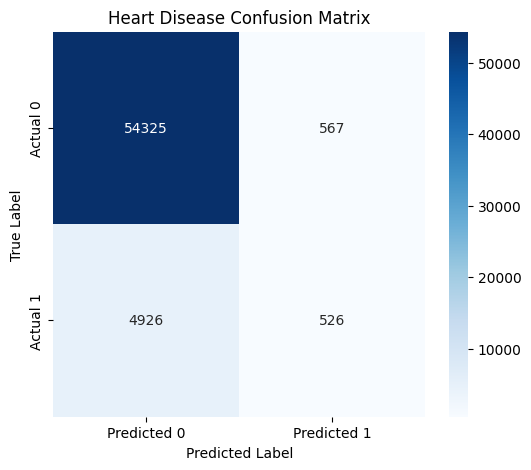

In [26]:
# 1. Evaluate on test set (your existing code)
test_loss, test_accuracy = model.evaluate(
    X_test_scaled,
    y_test,
    verbose=1
)

print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}\n")

# 2. Get continuous probability predictions
y_pred_probs = model.predict(X_test_scaled)

# 3. Convert probabilities to binary predictions (0 or 1)
y_pred = (y_pred_probs >= 0.5).astype(int)

# 4. Print Classification Report (Precision, Recall, F1-Score)
print("=" * 50)
print("CLASSIFICATION REPORT")
print("=" * 50)
print(classification_report(y_test, y_pred, target_names=['No Disease (0)', 'Heart Disease (1)']))

# 5. Generate and Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Predicted 0', 'Predicted 1'],
    yticklabels=['Actual 0', 'Actual 1']
)
plt.title('Heart Disease Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

### Notes - Baseline performence

We can't trust the 91% overall accuracy because the other results show a **severe class imbalance.**

Because 90% of the test set consists of healthy people (54,892 out of 60,344), the  model has learned to guess "No Disease" almost every time.

---

### Key Metric Breakdown

**1. Recall for Heart Disease = 0.10 (10%)**

* **What it means:** The model only detected **10% of people who actually have heart disease**.
* **Medical Impact:** Out of 5,452 sick patients, the model missed roughly 4,900 of them. It sent **9 out of 10 sick patients home**, telling them they were healthy.

**2. Precision for Heart Disease = 0.48 (48%)**

* **What it means:** When the model *does* guess someone has heart disease, it is wrong more than half the time.

**3. No Disease Metrics (0.92 Precision / 0.99 Recall)**

* **What it means:** The model is exceptionally good at identifying healthy people, simply because almost the entire dataset is healthy.


---

* **Core Weakness:** The model fails at its main task—detecting heart disease. It misses **90%** of positive cases.


* **Next Steps:**
1. **Handle Imbalance:** Use technique like `SMOTE` (oversampling), undersampling healthy cases, or setting `class_weight='balanced'` during training.
2. **Lower Threshold:** Drop the decision threshold from `0.5` to `0.2` or `0.1` so the model predicts "Heart Disease" more aggressively.
3. **Change Priority Metric:** Optimize the model for **Recall** instead of **Accuracy**.

-------

# Section 2 : Model 2
> Model 2 added a **Dropout layer with a rate of 0.3** after the first dense layer to reduce overfitting.

In [29]:
model_dropout = Sequential([
    Dense(64, activation="relu", input_shape=(n_features,)),
    Dropout(0.3),

    Dense(32, activation="relu"),

    Dense(1, activation="sigmoid")
])

In [30]:
model_dropout.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [31]:
history_dropout = model_dropout.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=50,
    batch_size=32
)

Epoch 1/50
6035/6035 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - accuracy: 0.9095 - loss: 0.2451 - val_accuracy: 0.9110 - val_loss: 0.2384
Epoch 2/50
6035/6035 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.9108 - loss: 0.2383 - val_accuracy: 0.9109 - val_loss: 0.2392
Epoch 3/50
6035/6035 ━━━━━━━━━━━━━━━━━━━━ 21s 3ms/step - accuracy: 0.9108 - loss: 0.2371 - val_accuracy: 0.9112 - val_loss: 0.2375
Epoch 4/50
6035/6035 ━━━━━━━━━━━━━━━━━━━━ 23s 3ms/step - accuracy: 0.9111 - loss: 0.2364 - val_accuracy: 0.9112 - val_loss: 0.2381
Epoch 5/50
6035/6035 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - accuracy: 0.9110 - loss: 0.2363 - val_accuracy: 0.9111 - val_loss: 0.2377
Epoch 6/50
6035/6035 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - accuracy: 0.9112 - loss: 0.2359 - val_accuracy: 0.9112 - val_loss: 0.2377
Epoch 7/50
6035/6035 ━━━━━━━━━━━━━━━━━━━━ 21s 3ms/step - accuracy: 0.9111 - loss: 0.2358 - val_accuracy: 0.9104 - val_loss: 0.2386
Epoch 8/50
6035/6035 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - accuracy: 0.9114 - loss: 0

### plotting the loss for Model 2

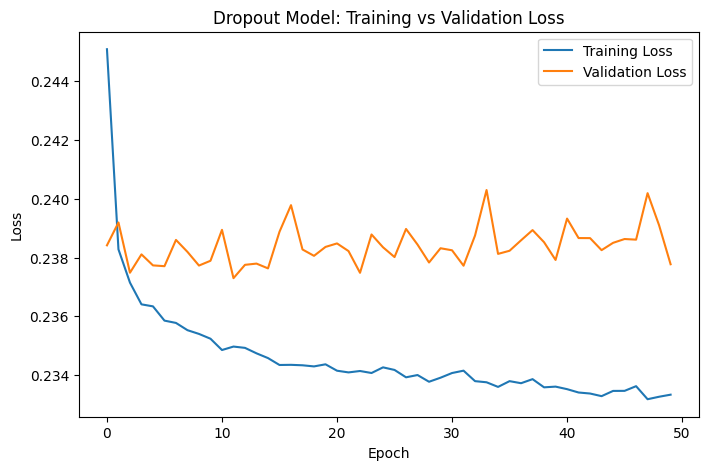

In [32]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_dropout.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_dropout.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Dropout Model: Training vs Validation Loss")
plt.legend()

plt.show()

### Evaluate the model on test set

In [33]:
dropout_test_loss, dropout_test_accuracy = model_dropout.evaluate(
    X_test_scaled,
    y_test
)

print(f"Test Loss: {dropout_test_loss:.4f}")
print(f"Test Accuracy: {dropout_test_accuracy:.2%}")

1886/1886 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9113 - loss: 0.2379
Test Loss: 0.2379
Test Accuracy: 91.13%


### Classification report and confusion matrix for model 2

1886/1886 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
                  precision    recall  f1-score   support

No Heart Disease       0.91      1.00      0.95     54892
   Heart Disease       0.62      0.04      0.08      5452

        accuracy                           0.91     60344
       macro avg       0.77      0.52      0.52     60344
    weighted avg       0.89      0.91      0.87     60344



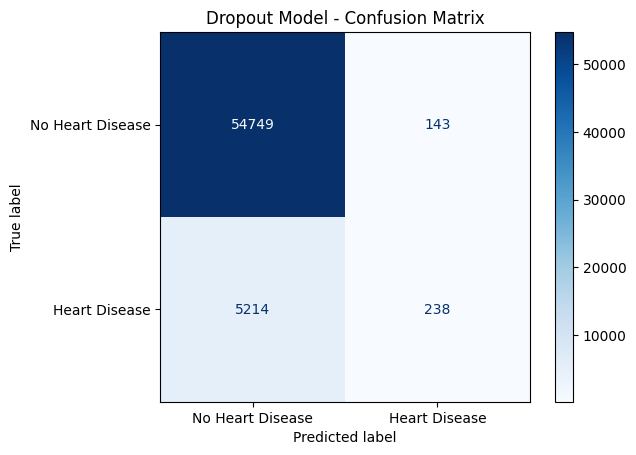

In [45]:
y_pred_prob = model_dropout.predict(X_test_scaled)
y_pred = (y_pred_prob >= 0.5).astype(int).ravel()

print(classification_report(
    y_test,
    y_pred,
    target_names=["No Heart Disease", "Heart Disease"]
))


cm = confusion_matrix(y_test, y_pred)

display_cm = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Heart Disease", "Heart Disease"]
)

display_cm.plot(cmap="Blues")
plt.title("Dropout Model - Confusion Matrix")
plt.show()

## Model 2 — Dropout Performance Report



Although Model 2 achieved **91% accuracy**, its performance on the minority class remains very poor. The **macro F1-score of 0.52** demonstrates the large difference in performance between the two classes.

The Dropout layer therefore **did not solve the main problem**. The model remains heavily biased toward predicting **No Heart Disease**, which is reflected by its perfect 1.00 recall for that class and extremely low 0.04 recall for the Heart Disease class.

This is particularly important because, for a heart disease prediction task, **missing actual heart disease cases is much more concerning than simply maximizing overall accuracy**.

### in short

> **Model 2, which incorporated a 30% Dropout layer to reduce overfitting, achieved 91% test accuracy. However, the model showed a strong bias toward the majority class. It achieved an F1-score of 0.95 and a recall of 1.00 for patients without heart disease, while the Heart Disease class had a precision of 0.62, recall of only 0.04, and an F1-score of 0.08. Therefore, despite maintaining a high overall accuracy, the model was unable to effectively identify positive heart disease cases. This indicates that Dropout alone did not address the class imbalance or improve the model's ability to detect the minority class.**


# Section 3 : Model 3 with early stopping

In [37]:
from tensorflow.keras.callbacks import EarlyStopping

model_dropout = Sequential([
    Dense(64, activation="relu", input_shape=(n_features,)),
    Dropout(0.3),

    Dense(32, activation="relu"),

    Dense(1, activation="sigmoid")
])

model_dropout.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_dropout = model_dropout.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping]
)

Epoch 1/50


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


6035/6035 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - accuracy: 0.9096 - loss: 0.2444 - val_accuracy: 0.9108 - val_loss: 0.2385
Epoch 2/50
6035/6035 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.9108 - loss: 0.2378 - val_accuracy: 0.9102 - val_loss: 0.2382
Epoch 3/50
6035/6035 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - accuracy: 0.9110 - loss: 0.2367 - val_accuracy: 0.9113 - val_loss: 0.2379
Epoch 4/50
6035/6035 ━━━━━━━━━━━━━━━━━━━━ 21s 3ms/step - accuracy: 0.9113 - loss: 0.2365 - val_accuracy: 0.9101 - val_loss: 0.2391
Epoch 5/50
6035/6035 ━━━━━━━━━━━━━━━━━━━━ 32s 5ms/step - accuracy: 0.9110 - loss: 0.2361 - val_accuracy: 0.9112 - val_loss: 0.2372
Epoch 6/50
6035/6035 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - accuracy: 0.9113 - loss: 0.2359 - val_accuracy: 0.9107 - val_loss: 0.2383
Epoch 7/50
6035/6035 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - accuracy: 0.9115 - loss: 0.2356 - val_accuracy: 0.9111 - val_loss: 0.2373
Epoch 8/50
6035/6035 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - accuracy: 0.9118 - loss: 0.2353 - val

### 1. Plot Training and Validation Loss

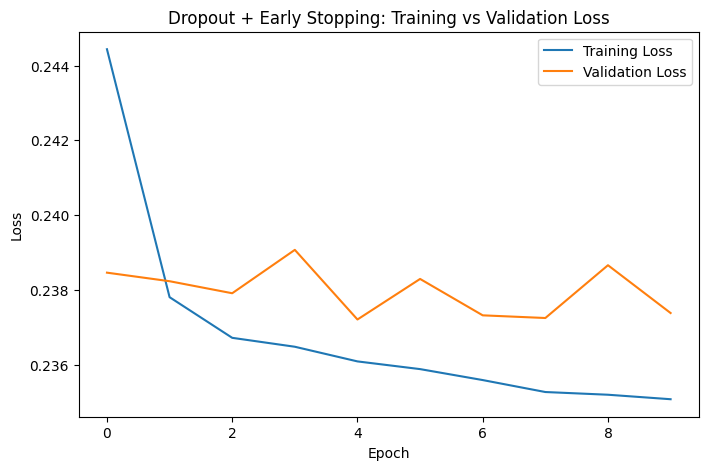

Epochs that run: 10


In [40]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_dropout.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_dropout.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Dropout + Early Stopping: Training vs Validation Loss")
plt.legend()

plt.show()
print("Epochs that run:", len(history_dropout.history["loss"]))

### 2. Evaluate on the Test Data

In [41]:
test_loss, test_accuracy = model_dropout.evaluate(
    X_test_scaled,
    y_test,
    verbose=1
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.2%}")

1886/1886 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9112 - loss: 0.2374
Test Loss: 0.2374
Test Accuracy: 91.12%


### 3. Make Predictions

In [42]:
y_pred_prob = model_dropout.predict(X_test_scaled)
y_pred = (y_pred_prob >= 0.5).astype(int).ravel()

1886/1886 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step


### 4. Print the Classification Report

In [43]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "No Heart Disease",
            "Heart Disease"
        ]
    )
)

                  precision    recall  f1-score   support

No Heart Disease       0.91      1.00      0.95     54892
   Heart Disease       0.62      0.04      0.08      5452

        accuracy                           0.91     60344
       macro avg       0.77      0.52      0.52     60344
    weighted avg       0.89      0.91      0.87     60344



### 5. Plot the Confusion Matrix

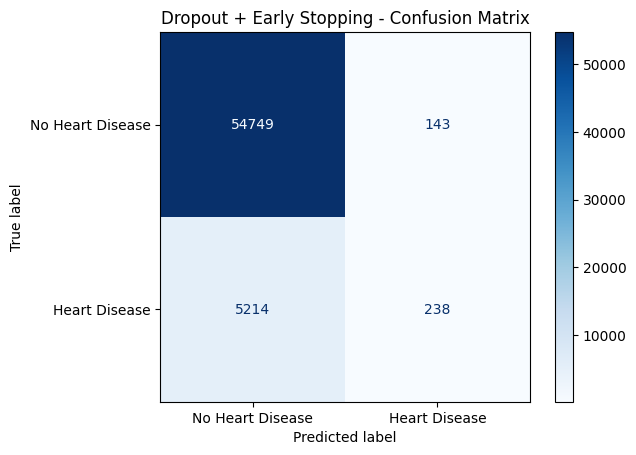

In [44]:
cm = confusion_matrix(
    y_test,
    y_pred
)

display_cm = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "No Heart Disease",
        "Heart Disease"
    ]
)

display_cm.plot(cmap="Blues")

plt.title("Dropout + Early Stopping - Confusion Matrix")

plt.show()

### Notes on model 3 performence

The model achieved an overall **accuracy of 91%**, which initially appears to be a strong result. However, the classification report shows that the model performs very differently for the two classes.

* **No Heart Disease:** The model performed very well, achieving **91% precision, 100% recall, and a 95% F1-score**. It successfully identified almost all patients without heart disease.

* **Heart Disease:** The model performed poorly on the positive class. Although its **precision was 62%**, its **recall was only 4%**, meaning that it detected only about **4% of the actual heart disease cases**. Its F1-score was also very low at **8%**.

### Interpretation
 Despite achieving 91% accuracy, the model is **not performing well at detecting heart disease cases**. The next step should focus on improving the model's ability to identify the minority `HeartDisease = 1` class rather than simply trying to increase overall accuracy.

The **macro average F1-score of 0.52** also reflects this imbalance in performance between the two classes.


# Section 4 :  Comparing between the three models

| Model                        | Special characteristic                              | Evaluation performance                                                                 |
| ---------------------------- | --------------------------------------------------- | -------------------------------------------------------------------------------------- |
| **Model 1 — Baseline**       | Basic `64 → 32 → 1` architecture, no regularization | **Accuracy:** 91% · **Macro F1:** 0.56 · **Heart Disease recall:** 0.10 · **F1:** 0.16 |
| **Model 2 — Dropout**        | Added **30% Dropout** to reduce overfitting         | **Accuracy:** 91% · **Macro F1:** 0.52 · **Heart Disease recall:** 0.04 · **F1:** 0.08 |
| **Model 3 — Early Stopping** | Stops training when validation loss stops improving | **Accuracy:** 91% · **Macro F1:** 0.52 · **Heart Disease recall:** 0.04 · **F1:** 0.08 |

### Best Model: **Model 1 — Baseline**

It achieved the highest **Macro F1 (0.56)** and better detection of heart disease (**10% recall**) compared with 4% for Models 2 and 3. All three had the same 91% accuracy, so accuracy alone doesn't distinguish them.
